# Pure-dephasing model

Here we describe how to simulate a two-level system interacting diagonally with its environment, that is, a system undergoing decoherence without energy relaxation — the so-called *pure-dephasing* regime.

The system Hamiltonian reads

$$
H_S = \frac{\Delta\epsilon}{2} \sigma_z
$$

where $\Delta\epsilon$ is the energy difference between levels and $V$ is the diabatic coupling between levels. Under these conditions, the system-bath interaction Hamiltonian takes the form

$$
H_{SB} = \frac{\sigma_z}{2} \otimes X_B,
$$

where $Q_S=\sigma_z$ and it is the system operator and

$$
X_B = \sum_j c_j x_j.
$$

The relevance of studying this model lies in its ability to describe open quantum systems where relaxation processes are much slower than decoherence. In addition, this represents the prototypical model for capturing the decoherence dynamics of two-level systems in condensed-phase environments.

In our model, we consider the Drude-Lorentz Spectral Density

$$ J(\omega) = \frac{2}{\pi}\frac{\lambda\omega\omega_c}{\omega_c^2 + \omega^2}$$

## Setup

Once *TENSO* is installed, the necessary libraries can be imported to begin the simulations. TENSO provides an auxiliary function designed to construct the bath correlation function in a systematic and efficient way. Additionally, it includes the `spin_boson` integrator, which conveniently incorporates all system parameters, enabling the simulation of open quantum dynamics within the spin-boson framework.


In [4]:
from math import ceil
import os
import json as json
import numpy as np
from tqdm import tqdm

from tenso.prototypes.heom import spin_boson #Spin-boson helper function
from tenso.prototypes.bath import gen_bcf #Bath correlation function generator
import matplotlib.pyplot as plt

In [ ]:
out = "pd_result_300K" #To store the results

## Bath Correlation Function (BCF)

The bath correlation function encodes all the essential information required to capture the influence of the environment on the reduced density matrix of the system, $\rho_S(t)$. It is defined as

$$
C(t)=\mathrm{Tr}\bigl(\tilde{X}_B(t)\,\tilde{X}_B(0)\,\rho_B^{\mathrm{eq}}\bigr),
$$

and is related to the spectral density $J(\omega)$ through

$$
C(t)=\int_{-\infty}^{\infty} \mathcal{J}(\omega)(1-e^{-\beta \omega})^{-1}e^{-i\omega t}\mathrm{d}\omega
$$
Where $\mathcal{J}(\omega)$ is the odd extention of $J(\omega)$, and is defined as $\mathcal{J}(\omega)=|g|^2\delta(\omega-\omega_j)+\delta(\omega+\omega_j)$

TENSO provides two approaches for decomposing the bath correlation function into sums of exponentials: the Matsubara and the Padé schemes. In this example, we focus on the Padé decomposition following the $\left( N - 1 \right)/N$ scheme. In general, such decompositions take the form

$$
C(t) = \sum_{k=1}^{K} c_k e^{  \gamma_k t}\quad \mathrm{and} \quad C^*(t) = \sum_{k=1}^{K} \bar{c_k} e^{  \gamma_k t}
$$

The `get_bcf` function accepts different arguments depending on the choice of spectral density and decomposition method. For a Drude-Lorentz spectral density combined with a Padé decomposition, the main parameters are:

- `re_d`: The Drude-Lorentz reorganization energy, $\lambda$. This parameter should be provided as a list.
- `width_d`: The cutoff frequency for the Drude-Lorentz SD, also specified as a list.
- `temperature`: The bath temperature in K (float).
- `decomposition_method`: The method used for the decomposition of the BCF (string).
- `n_ltc`: The number of low-temperature corrections.


In [35]:
bath_simulation = gen_bcf(
    re_d=[540],    #Reorganization energy in cm-1
    width_d=[70],  #Width of the spectral density in cm-1
    temperature=300, #Temperature in Kelvin
    decomposition_method='Pade', #Decomposition method for the bath correlation function
    n_ltc=1, #Number of low-temperature correction terms
)
#print(bath_simulation, flush=True)

## `n_ltc` effect

To explore how the parameter `n_ltc` influences the bath correlation function, we examined a range of values. Even with an exceedingly large number of low-temperature corrections, it is evident that the real part of the correlation function exhibits noticeable changes at very short times as `n_ltc` increases. However, these variations generally occur on a very small scale that does not significantly impact the overall accuracy of the dynamics.


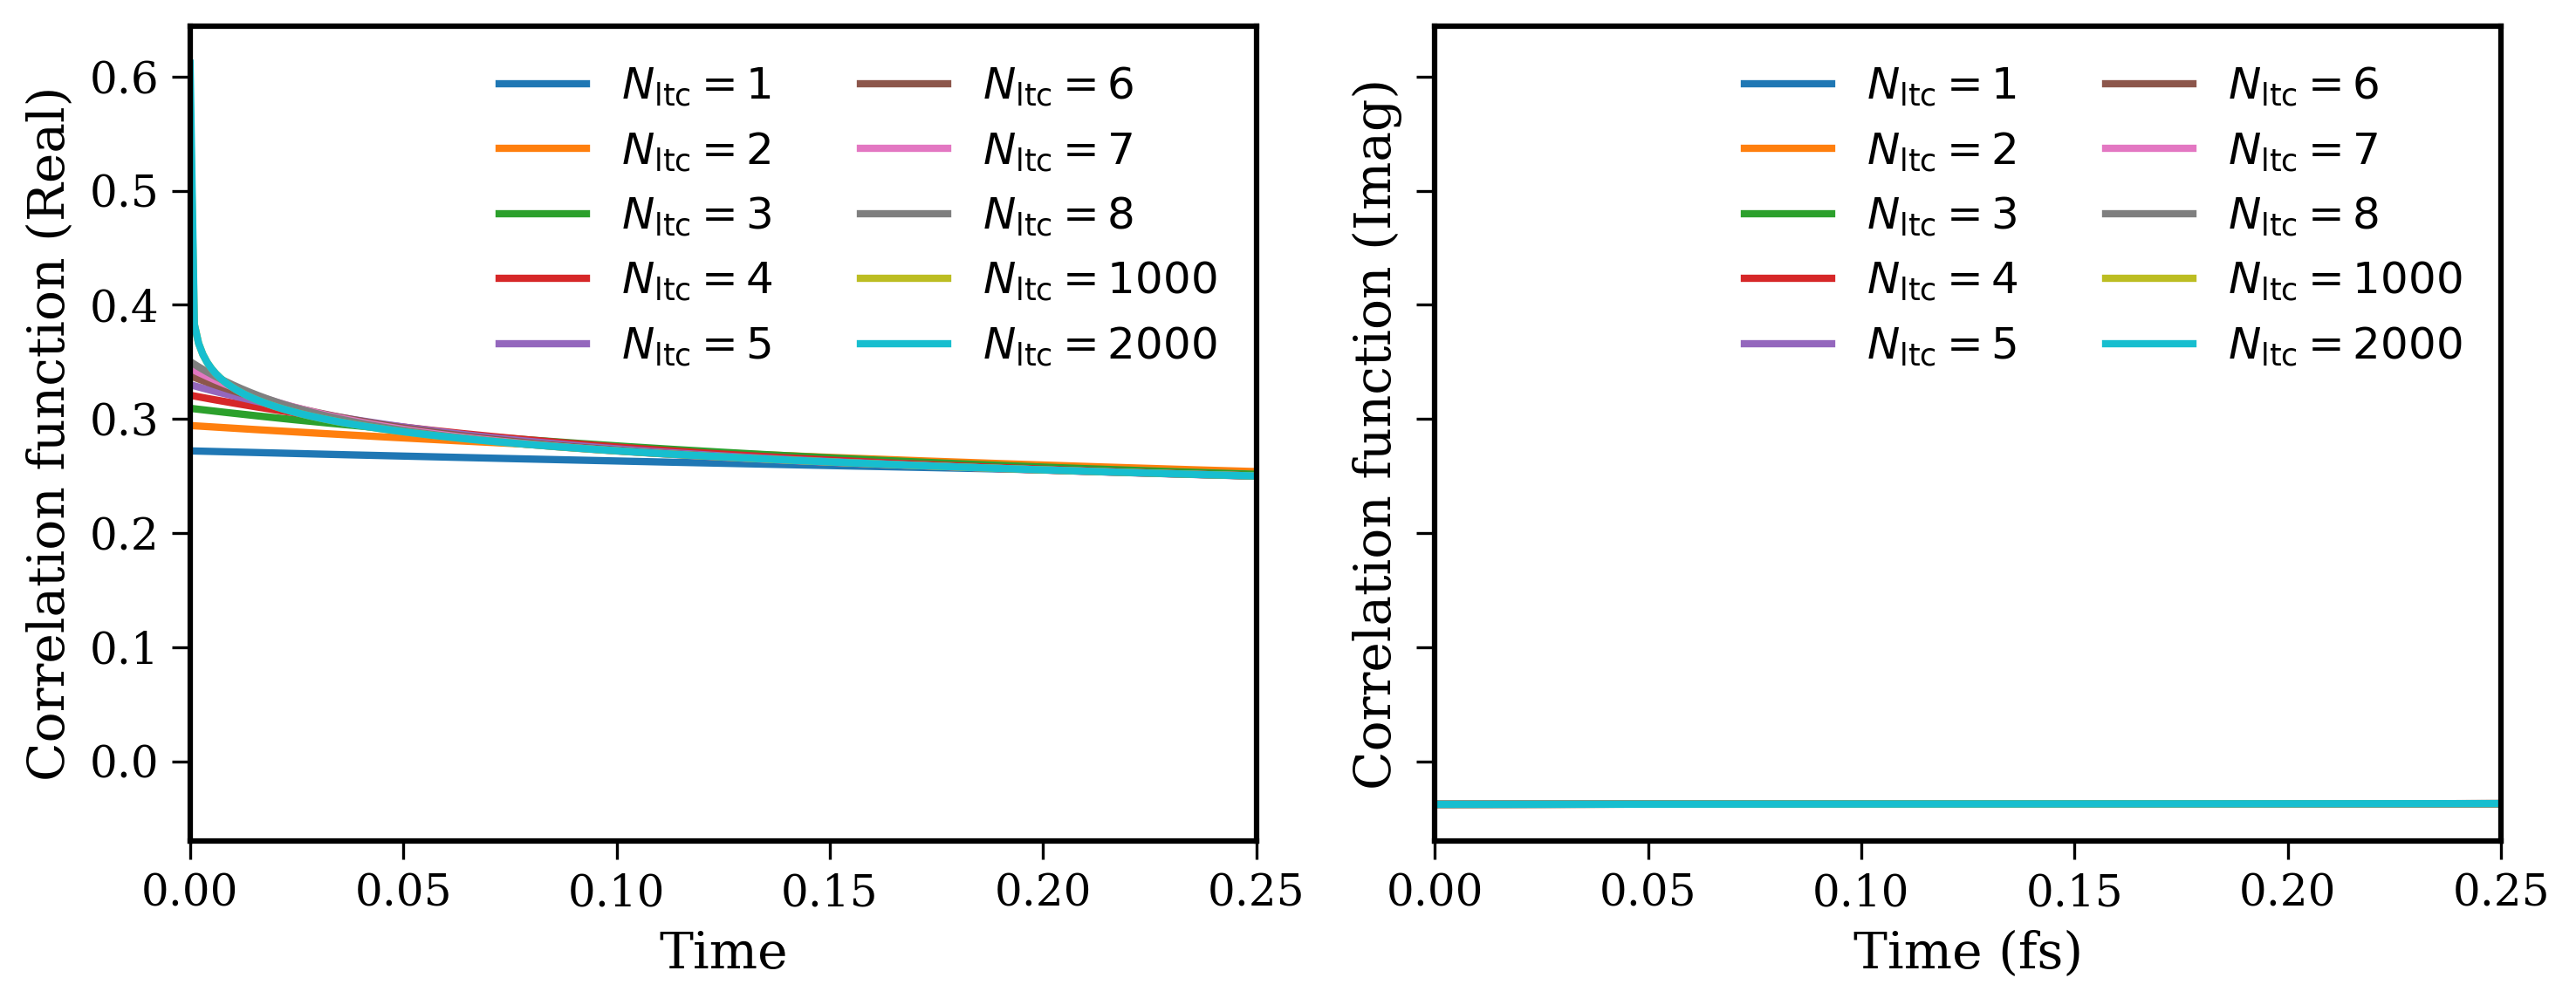

In [36]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.fontsize': 12,
    'figure.dpi': 300,
})

t = np.linspace(0, 10, 10000)

fig, (ax_real, ax_imag) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

def plot_bcf(n_ltc):
    bath = gen_bcf(
        re_d=[540],
        width_d=[70],
        temperature=300,
        decomposition_method='Pade',
        n_ltc=n_ltc,
    )
    #print(bath, flush=True)

    ax_real.plot(t, bath.real_correlation_function(t), label=fr'$N_{{\rm ltc}}={n_ltc}$')
    ax_imag.plot(t, bath.imag_correlation_function(t), label=fr'$N_{{\rm ltc}}={n_ltc}$')

for n_ltc in [1, 2, 3, 4, 5, 6, 7, 8, 1000, 2000]:
    plot_bcf(n_ltc)

ax_real.set_xlabel('Time')
ax_real.set_ylabel(r'Correlation function (Real)')
ax_real.legend(frameon=False, ncol=2)
ax_real.set_xlim(0, 0.25)
ax_real.grid(False)

ax_imag.set_xlabel('Time (fs)')
ax_imag.set_ylabel(r'Correlation function (Imag)')
ax_imag.legend(frameon=False, ncol=2)
ax_imag.set_xlim(0, 0.25)
ax_imag.grid(False)

plt.tight_layout()
plt.savefig('bath_correlation_horizontal.png', dpi=300, transparent=True)
plt.show()



## Evolution parameters and $\rho_S(0)$

Since **TENSO** is designed to handle realistic systems and structured environments, its default time units are typically expressed in femtoseconds (fs). Nevertheless, these units can be modified depending on the specifics of the simulation.

- `end_time`: Final simulation time, specified in femtoseconds.
- `dt`: Time step used for the integration of the dynamics.
- `wfn`: Initial state of the system. In this case, the system starts in the coherent superposition

  $$
  |\Psi\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle + |1\rangle \right).
  $$


In [25]:
end_time = 400.0 #fs
dt = 1.0
wfn = np.array([1.0, 1.0], dtype=np.complex128) / np.sqrt(2.0)

## Spin-Boson Propagator

**TENSO** provides an auxiliary function to simulate two-level systems, namely `spin_boson()`. This function gathers all parameters related to the system, the propagation scheme, and the influence of the bath on the system dynamics.

- `fname`: Specifies the output file name. In this example, it is `"pd_result_300K"`, corresponding to the `out` variable.
- `init_rdo`: Represents the outer product between $|\Psi\rangle$ and $\langle \Psi|$. Here, $|\Psi\rangle$ corresponds to the `wfn` variable. This argument defines the initial reduced density operator of the system.
- `sys_ham`: The system Hamiltonian. It can be diagonal or include off-diagonal elements. In this example, no off-diagonal terms are considered.
- `sys_op`: The system operator ($Q_S$) entering the system-bath interaction Hamiltonian ($H_{SB}$).
- `bath_correlation`: The bath correlation function (BCF) generated using `get_bcf()`. In this case, it is stored in the `bath_simulation` variable.
- `dim`: The hierarchy depth. Higher values of `dim` typically yield more accurate results.
- `end_time`: Final time of the simulation.
- `step_time`: Time step (`dt`) used for propagation.

`**tqdm**` is employed to display the progress bar during the simulation runtime.


In [33]:
propagator = spin_boson(
        fname=out,
        init_rdo=np.outer(wfn, wfn.conj()),
        sys_ham=np.array([[0.0, 0.0], [0.0, 0.0]], dtype=np.complex128),
        sys_op=np.array([[0.5, 0.0], [0.0, -0.5]], dtype=np.complex128),
        bath_correlation=bath_simulation,
        dim=40,
        end_time=end_time,
        step_time=dt,
        save_checkpoint_to_file=True,
    )
progress_bar = tqdm(propagator, total=ceil(end_time / dt))
for _t in (progress_bar):
    progress_bar.set_description(f'@{_t:.2f} fs')


  0%|          | 0/400 [00:00<?, ?it/s]

{'dim': 40, 'end_time': 400.0, 'step_time': 1.0, 'save_checkpoint_to_file': True}
{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 40, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 400.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 64, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': True, 'start_time': 0.0, 'step_time': 1.0, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.22307229 | e:0.00000000 | a:-0.03780000 | f:0.47230529 | f^2:0.22307229
For k=1: s:0.04889143 | e:0.00000000 | a:0.00000000 | f:0.22111406 | f^2:0.04889143


@399.00 fs: 100%|██████████| 400/400 [00:26<00:00, 15.34it/s]


## Plotting TENSO results against the Analytical pure-dephasing

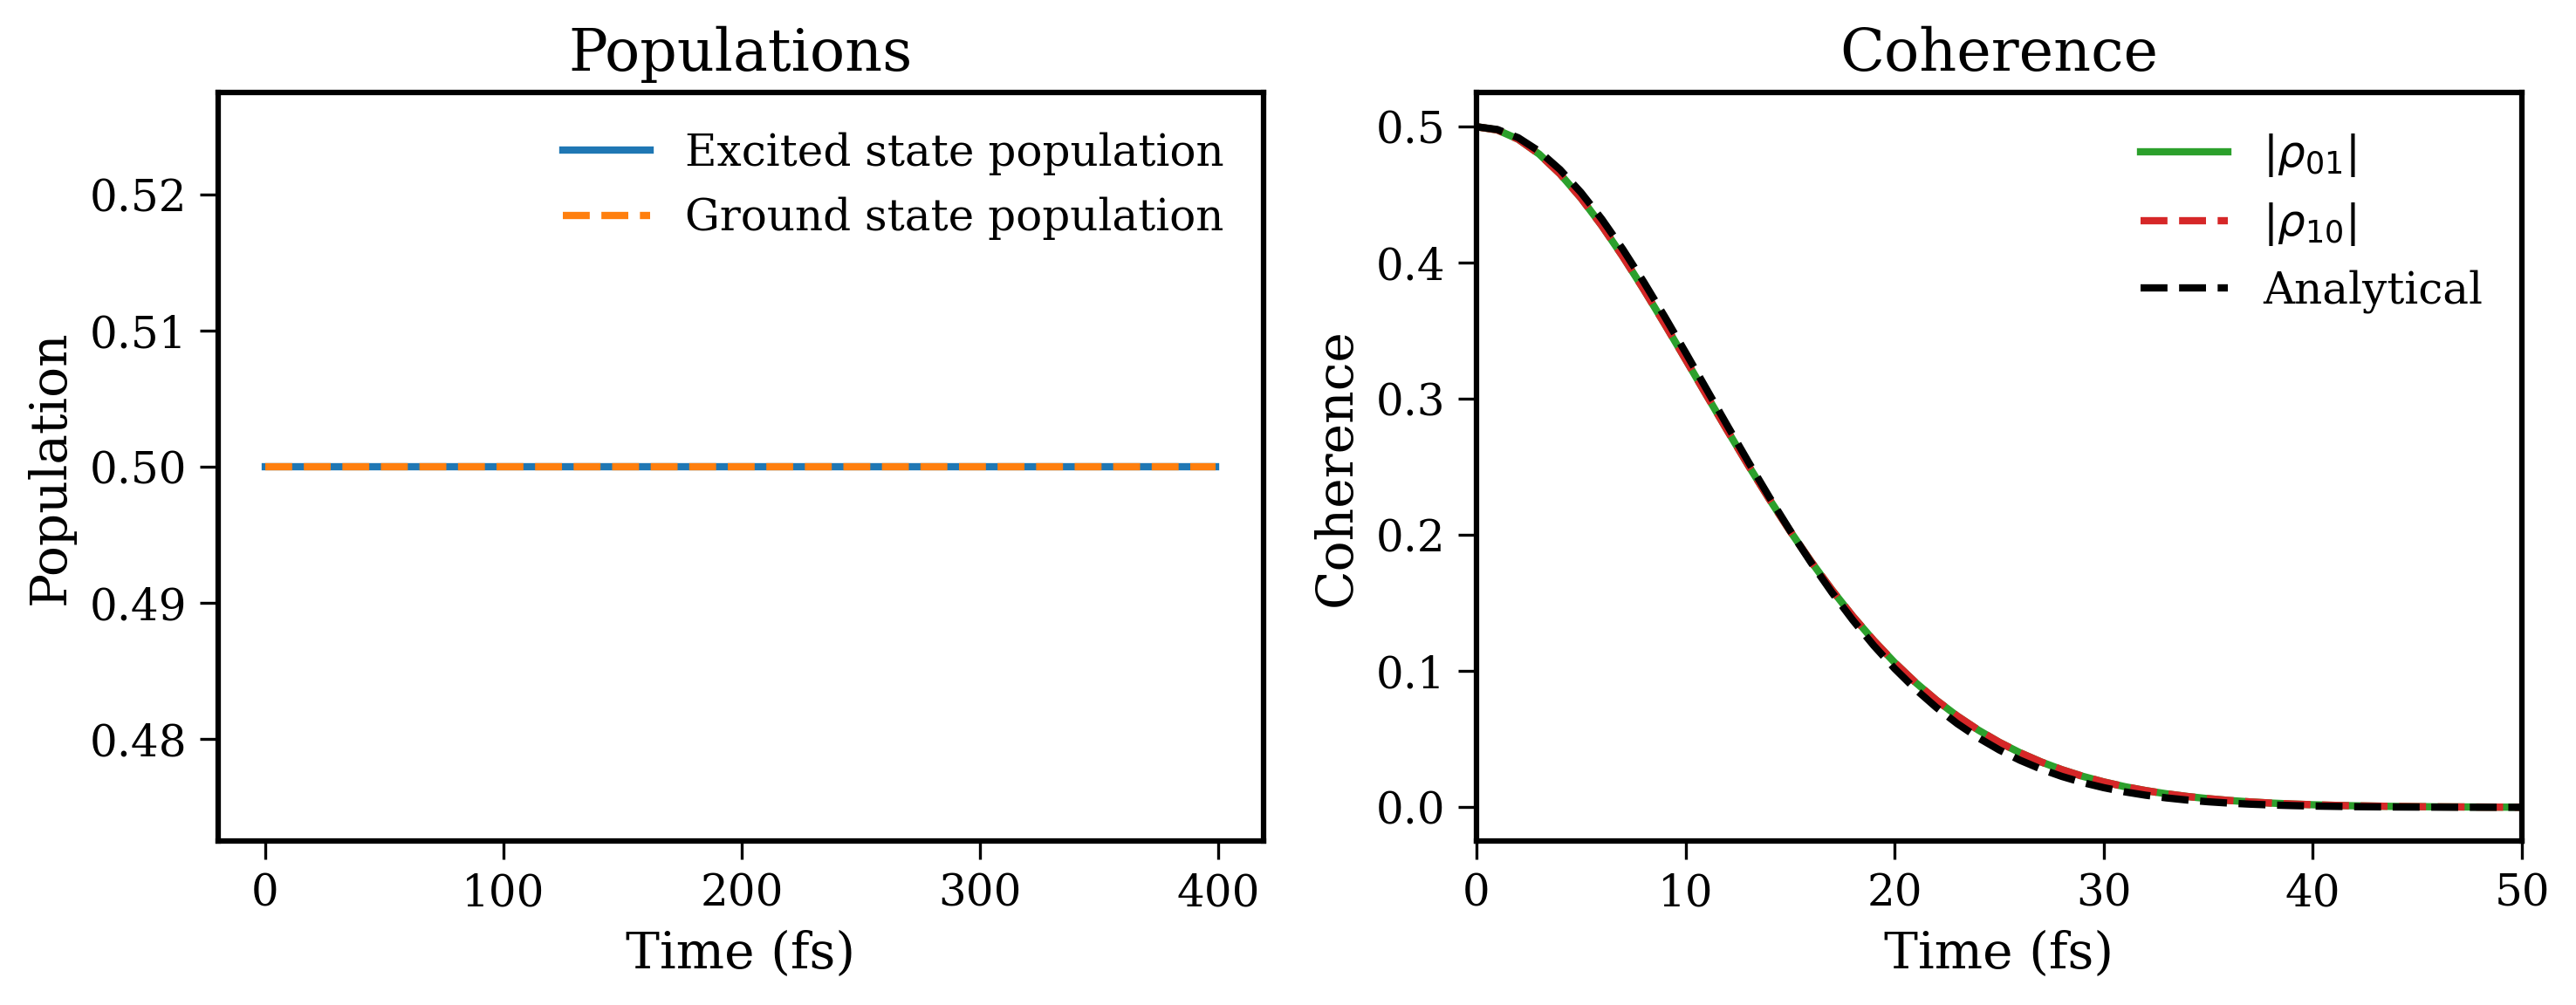

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.fontsize': 12,
    'figure.dpi': 300,
})

# --- Constants---
hbar_fs_cm = 5308.837458877  # hbar en (fs*cm^-1)
kB_cmK = 0.69503476          # (cm^-1)/K

# --- Drude-Lorentz spectral density ---
def J_drude(omega_fs, lambda_cm, wc_cm):
    c_cm_per_fs = 2.99792458e-5  # cm^-1/fs^-1
    wc_fs = wc_cm * c_cm_per_fs
    return (2 / np.pi) * lambda_cm * wc_cm * c_cm_per_fs * omega_fs / (omega_fs**2 + wc_fs**2)

# --- Pure dephasing function ---
def Gamma_pure_dephasing(t_fs, T_K, lambda_cm=540, wc_cm=70.0):
    omega = np.linspace(1e-6, 0.5, 2000)  # fs^-1
    Jw = J_drude(omega, lambda_cm, wc_cm)
    
    beta = 1.0 / (kB_cmK * T_K)
    coth = 1.0 / np.tanh(0.5 * hbar_fs_cm * omega * beta)
    
    integrand = Jw * coth * (1 - np.cos(omega * t_fs)) / omega**2
    Gamma = simpson(integrand, omega) / hbar_fs_cm
    return Gamma

# --- Read data ---
filename = 'pd_result_300K.dat.log'  
data = np.loadtxt(filename, delimiter=' ', dtype=complex)

t_fs = data[:, 0].real
pop_exc = data[:, 1].real
coh_01 = np.abs(data[:, 2])
coh_10= np.abs(data[:, 3])
pop_gnd = data[:, 4].real

# --- Pure dephasing ---
Gamma_vals = np.array([Gamma_pure_dephasing(t, 300) for t in t_fs])
pd_env = np.exp(-Gamma_vals)

# --- Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=False)

# Left Panel: Populations
ax1.plot(t_fs, pop_exc, '-', color='C0', label='Excited state population')
ax1.plot(t_fs, pop_gnd, '--', color='C1', label='Ground state population')
ax1.set_ylabel('Population')
ax1.set_title('Populations')
ax1.set_xlabel('Time (fs)')
ax1.legend(frameon=False)
ax1.grid(False)

# Right Panel: Coherence
ax2.plot(t_fs, coh_01, '-', color='C2', label=r'$|\rho_{01}|$')
ax2.plot(t_fs, coh_10, '--', color='C3', label=r'$|\rho_{10}|$')
ax2.plot(t_fs, 0.5 * pd_env, '--', color='k', label='Analytical')
ax2.set_xlabel('Time (fs)')
ax2.set_ylabel('Coherence')
ax2.set_title('Coherence')
ax2.legend(frameon=False)
ax2.set_xlim(0, 50)
ax2.grid(False)

plt.tight_layout()
plt.savefig('combined_plot_puredephasing_horizontal.png', dpi=300, transparent=True)
plt.show()
